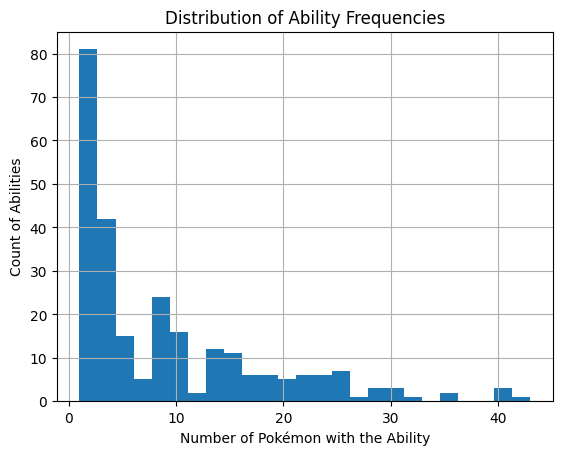

In [ ]:
### --- How Frequent are Each Abilities --- ###
# Import pandas
import pandas as pd
import matplotlib.pyplot as plt


# Get the CSV
df = pd.read_csv("pokedex.csv")

columnsDrop = ['german_name','japanese_name','type_number']

df_cleaned = df.drop(columnsDrop, axis=1)


# Analyzing the frequency of abilities
df_abilities = df_cleaned[['ability_1','ability_2','ability_hidden']]

all_abilities = df_abilities.stack()

total_ability_counts = all_abilities.value_counts().reset_index()
total_ability_counts.columns = ['Ability', 'Total_Count']

ax = total_ability_counts.hist('Total_Count', bins=25)[0][0]
ax.set_title('Distribution of Ability Frequencies')
ax.set_xlabel('Number of Pokémon with the Ability')
ax.set_ylabel('Count of Abilities')

ax.get_figure().savefig('abilityFrequency.png', bbox_inches='tight', dpi=300)

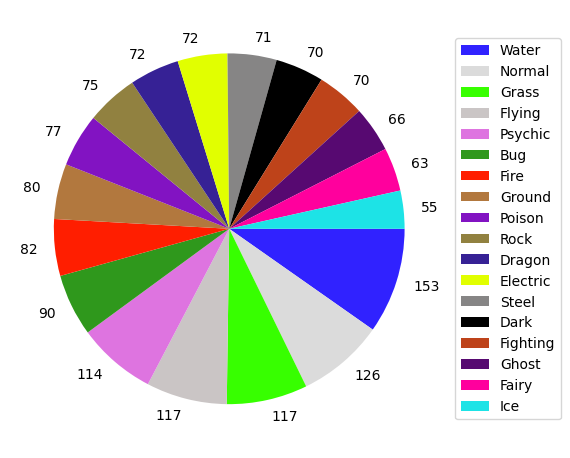

In [ ]:
### --- How Frequent are Each Types --- ###
import matplotlib.pyplot as plt
import pandas as pd

# Analyzing Type Frequency

df_types = df_cleaned[['type_1','type_2']]
df_types_clean = df_types.stack()

# Sort the type_counts
type_count = df_types_clean.value_counts().reset_index()
type_count.columns = ['Type', 'Frequency']
type_count = type_count.sort_values(by='Frequency', ascending=False)

# Colors to match to the right type-- we dont want red for water lol
color_list = ["#3022FF", "#DBDBDB", "#37FF00", "#CAC5C5", "#DE74E0", "#2F981C", "#FF1E00", "#B2783E", "#8213C2", "#918140", "#362195", "#E1FF00", "#868585", "#000000", "#BE431A", "#570971", "#FF009D", "#1DE3E6"]

# Make the Pie Chart
ax = type_count.plot(kind='pie', y='Frequency', colors=color_list, labels=type_count['Frequency'], counterclock=False,)

# Set The Legend Properly
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), labels = type_count['Type'])

plt.tight_layout()
plt.show()

ax.get_figure().savefig('TypeFrequency.png', bbox_inches='tight', dpi=300)


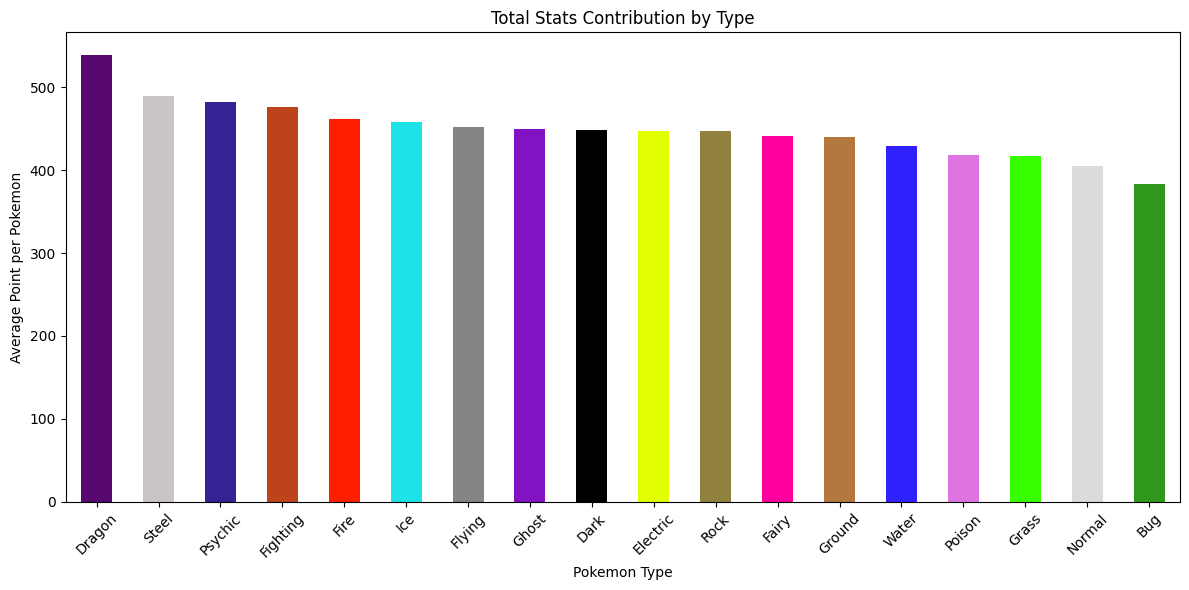

In [ ]:
### --- Sorting Each Type by Points --- ###
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pokedex.csv")
df_cleaned = df.drop(['german_name', 'japanese_name', 'type_number'], axis=1)

### --- Below Code Copied from Gemini --- ###

# 2. Reshape the data so each type is paired with its points
# Using melt ensures 'total_points' follows 'type_1' and 'type_2' correctly
df_melted = df_cleaned.melt(id_vars=['total_points'], value_vars=['type_1', 'type_2'], value_name='Type')
df_melted = df_melted.dropna(subset=['Type'])

# 3. Average
type_avg = df_melted.groupby('Type')['total_points'].mean().sort_values(ascending=False)

# 4. Color Mapping (Matching names to hex codes)
# This ensures the color follows the Type name, not the bar position
color_map = {
    "Water": "#3022FF", "Normal": "#DBDBDB", "Grass": "#37FF00", 
    "Steel": "#CAC5C5", "Poison": "#DE74E0", "Bug": "#2F981C", 
    "Fire": "#FF1E00", "Ground": "#B2783E", "Ghost": "#8213C2", 
    "Rock": "#918140", "Psychic": "#362195", "Electric": "#E1FF00", 
    "Fighting": "#BE431A", "Dark": "#000000", "Dragon": "#570971", 
    "Fairy": "#FF009D", "Ice": "#1DE3E6", "Flying": "#868585"
}

# Create a list of colors in the order of our sorted 'type_points'
current_colors = [color_map.get(t, "#808080") for t in type_avg.index]

# 5. Plotting
plt.figure(figsize=(12, 6))
ax = type_avg.plot(kind='bar', color=current_colors)

plt.title('Total Stats Contribution by Type')
plt.ylabel('Average Point per Pokemon')
plt.xlabel('Pokemon Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

ax.get_figure().savefig('TypePoints.png', bbox_inches='tight', dpi=300)


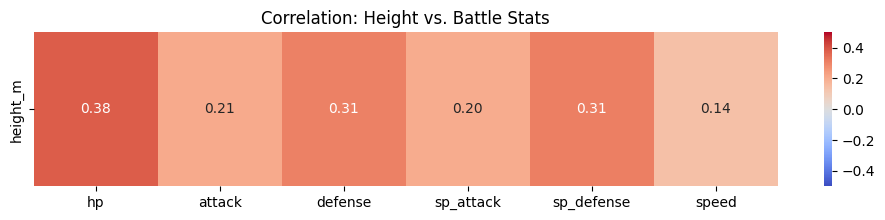

<Figure size 640x480 with 0 Axes>

In [13]:
### --- Linking Height to Points --- ###

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn makes heatmaps much easier than Matplotlib

df = pd.read_csv("pokedex.csv")
df_cleaned = df.drop(['german_name', 'japanese_name', 'type_number'], axis=1)

# Get the different attributes
stats_cols = ['height_m', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

# Create Matrix for stats
corr = df_cleaned[stats_cols].corr()


### --- Heat Map Code from Gemini --- ###

# 1. Get the 'height_m' row (this gives us 1 row, 7 columns)
height_row = corr.loc[['height_m']]

# 2. FORCE drop the 'height_m' column to get rid of the 1.0
# We use errors='ignore' just in case it was already dropped
height_only_corr = height_row.drop(columns=['height_m'], errors='ignore')

# 3. Double Check: If it's STILL there, we slice by position instead
if 'height_m' in height_only_corr.columns:
    height_only_corr = height_only_corr.iloc[:, 1:] 

# 4. Create the heatmap
plt.figure(figsize=(12, 2))
# Adding vmin and vmax ensures the colors scale to the ACTUAL stats, not 1.0
sns.heatmap(height_only_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-0.5, vmax=0.5)

plt.title('Correlation: Height vs. Battle Stats')
plt.show()
plt.savefig('Height vs Stats.png', dpi=300, bbox_inches='tight')

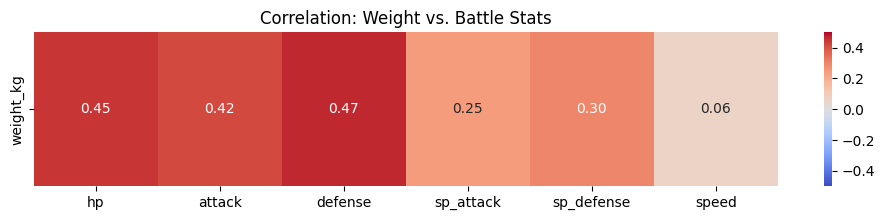

In [14]:
### --- Linking Weight to Points --- ###

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn makes heatmaps much easier than Matplotlib

df = pd.read_csv("pokedex.csv")
df_cleaned = df.drop(['german_name', 'japanese_name', 'type_number'], axis=1)

# Get the different attributes
stats_cols = ['weight_kg', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

# Create Matrix for stats
corr = df_cleaned[stats_cols].corr()


### --- Heat Map Code from Gemini --- ###

# 1. Get the 'height_m' row (this gives us 1 row, 7 columns)
weight_row = corr.loc[['weight_kg']]

# 2. FORCE drop the 'height_m' column to get rid of the 1.0
# We use errors='ignore' just in case it was already dropped
weight_only_corr = weight_row.drop(columns=['weight_kg'], errors='ignore')

# 3. Double Check: If it's STILL there, we slice by position instead
if 'weight_kg' in weight_only_corr.columns:
    weight_only_corr = weight_only_corr.iloc[:, 1:] 

# 4. Create the heatmap
plt.figure(figsize=(12, 2))
# Adding vmin and vmax ensures the colors scale to the ACTUAL stats, not 1.0
sns.heatmap(weight_only_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-0.5, vmax=0.5)

plt.title('Correlation: Weight vs. Battle Stats')
plt.savefig('Weight vs Stats.png', dpi=300, bbox_inches='tight')